# 01 — TBXT SPR Data Preparation

This notebook is the single source of truth for preparing the TBXT SPR binding affinity
dataset for downstream modeling. It reads the **raw password-protected Excel files** from
`data/zenodo/`, merges them, resolves compound structures via SMILES lookup tables,
and exports modeling-ready CSVs.

---

## Data provenance

**Source:** HD Biosciences performed surface plasmon resonance (SPR) binding affinity screens
of low-molecular-weight compounds against human TBXT (Brachyury). Raw data were released on
[Zenodo](https://zenodo.org/) as 15 password-protected Excel files spanning October 2020
through January 2023.

**Compound sources:**

| Prefix | Supplier | Notes |
|--------|----------|-------|
| `CF-*` | Piramal Pharma Solutions ("CF Labs") | Series CF-2 through CF-10 |
| `UNC-*` | UNC Chapel Hill (Drewry lab) | UNC-AH, UNC-ZDG, UNC-HO series |
| `CSC*` | ChemSpace | Catalog compounds |
| `MCULE-*` | MCULE | Virtual screening hits |
| numeric IDs | ChemSpace / other vendors | Catalog numbers without prefix |
| `M567200` | ChemSpace (reference compound) | Positive control across experiments |

**SMILES resolution cascade:**
1. Manual override for reference compound M567200/CSC015274258
2. `data/zenodo/ID with SMILES.xlsx` (~2,100 entries)
3. `data/Naar_SMILES.xlsx` (~135 entries)

**Key exclusion:** The `20210719` batch is excluded because 114 of its compound IDs
lack SMILES in any available lookup source (proprietary Piramal/ChemSpace catalog IDs).

---

## Pipeline summary

1. **Decrypt & parse** each raw xlsx file (15 files, password-protected)
2. **Extract** compound names and KD values from heterogeneous layouts
3. **Merge** into a single table with batch provenance
4. **Resolve** SMILES via lookup files
5. **Filter** to records with both SMILES and pKD
6. **Remove** ambiguous compound IDs (1 ID mapping to multiple SMILES)
7. **Assign** supplier labels from compound ID prefixes
8. **Average** replicates within each experiment batch
9. **Validate** SMILES with RDKit; canonicalize
10. **Compute** molecular properties; flag Chordoma Foundation filter compliance
11. **QC visuals:** distributions, per-batch, per-supplier breakdowns
12. **Collapse** to one row per unique compound
13. **Export** clean CSVs for modeling

In [1]:
from pathlib import Path
import io
import re
import warnings

import matplotlib.pyplot as plt
import msoffcrypto
import numpy as np
import openpyxl
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.95)

DATA_DIR = Path("../data")
ZENODO_DIR = DATA_DIR / "zenodo"
assert ZENODO_DIR.exists(), f"Missing {ZENODO_DIR}"

XLSX_FILES = sorted(ZENODO_DIR.glob("2*.xlsx"))
print(f"Found {len(XLSX_FILES)} raw experiment files")
for f in XLSX_FILES:
    print(f"  {f.name}")

Found 15 raw experiment files
  20200928 LMW binding affinity screen for 178 Piramal compounds.xlsx
  20201028 LMW binding affinity screen for 136 UNC and Piramal compounds.xlsx
  20201029 LMW binding affinity screen for 136 Chemspace and UNC compounds.xlsx
  20210126 LMW binding affinity screen for 136 compounds.xlsx
  20210312 LMW binding affinity screen for 136 compounds (from UNC and Piramal).xlsx
  20210423 LMW binding affinity screen for 136 compounds (from Chemspace and Piramal）.xlsx
  20210526 LMW binding affinity screen for 136 compounds (from UNC and Piramal).xlsx
  20210616 LMW binding affinity screen for 136 compounds (from ChemSpace and Piramal).xlsx
  20210707 LMW binding affinity screen for 136 compounds (from ChemSpace).xlsx
  20210719 LMW binding affinity screen for 136 compounds (from ChemSpace and Piramal).xlsx
  20210823 LMW binding affinity screen for 136 compounds (from Piramal and UNC).xlsx
  20211012 LMW binding affinity screen for 136 compounds (from Piramal an

---
## 1. Decrypt and parse raw xlsx files

Each file is password-protected (password: `HDB`) and contains a "Data summary" sheet
with compound-level binding affinity measurements. The files have heterogeneous header
layouts that we handle programmatically.

**KD extraction:** Each file contains 1–3 columns reporting equilibrium dissociation
constants: `KD (M)` (kinetics-derived and/or affinity-derived) and `KD` (bare, also in
Molar). We coalesce across all KD columns per row, taking the first non-null value.
This maximizes coverage since different compounds may have measurements from different
fitting models (kinetics vs. steady-state affinity).

In [2]:
PASSWORD = "HDB"
EXCLUDE_DATES = {"20210719"}

M567200_SMILES = "O=S(=O)(c1ccc(-c2ccc3[nH]c(-c4ccccn4)nc3c2)cc1)N1CCOCC1"

ANNOTATION_PATTERNS = [
    r"^\*",
    r"(?i)^Running buffer",
    r"(?i)^All test compound",
    r"(?i)^compounds? M567200",
    r"(?i)^Reference .+ compound",
    r"(?i)^Reference .+ was tested",
    r"(?i)screened from \d+ [uU]M",
    r"(?i)top dose",
    r"(?i)^Analyte 1 Solution$",
    r"(?i)^Contact time",
    r"(?i)^Dissociation time",
    r"(?i)^Flow rate",
]


def _is_annotation(name: str) -> bool:
    return any(re.search(p, name) for p in ANNOTATION_PATTERNS)


def open_xlsx(path: Path) -> openpyxl.Workbook:
    try:
        with open(path, "rb") as fh:
            of = msoffcrypto.OfficeFile(fh)
            of.load_key(password=PASSWORD)
            buf = io.BytesIO()
            of.decrypt(buf)
            buf.seek(0)
        return openpyxl.load_workbook(buf, read_only=True, data_only=True)
    except msoffcrypto.exceptions.DecryptionError:
        return openpyxl.load_workbook(path, read_only=True, data_only=True)


def find_data_summary_sheet(wb: openpyxl.Workbook) -> str:
    for s in wb.sheetnames:
        if "data summary" in s.strip().lower():
            return s
    raise ValueError(f"No Data summary sheet in {wb.sheetnames}")


def extract_records(path: Path) -> pd.DataFrame:
    date_str = path.name[:8]
    wb = open_xlsx(path)
    ds = find_data_summary_sheet(wb)
    ws = wb[ds]

    all_rows = []
    for row in ws.iter_rows(max_col=25, values_only=True):
        all_rows.append(list(row))
    wb.close()

    header_idx, header = _find_header(all_rows)
    cpd_col = _find_compound_col(header)
    kd_cols = _find_all_kd_cols(header)

    records = []
    for row in all_rows[header_idx + 1:]:
        if len(row) <= cpd_col:
            continue
        raw_name = row[cpd_col]
        if raw_name is None or str(raw_name).strip() == "":
            continue
        raw_name = str(raw_name).strip()
        if _is_annotation(raw_name):
            continue

        kd_val = _coalesce_kd(row, kd_cols)
        records.append({
            "raw_compound": raw_name,
            "KD_M": kd_val,
            "reference_date": date_str,
        })

    return pd.DataFrame(records)


def _find_header(rows: list[list]) -> tuple[int, list[str]]:
    for i, r in enumerate(rows[:5]):
        vals = [str(c).strip() if c is not None else "" for c in r]
        if any("KD" in v and v != "KD report" for v in vals):
            return i, vals
    raise ValueError("Could not find header row with KD column")


def _find_compound_col(header: list[str]) -> int:
    candidates = [
        "Compounds", "Compound ID", "Analyte 1 Solution", "Comments",
    ]
    for target in candidates:
        for i, h in enumerate(header):
            if h.strip().lower() == target.strip().lower():
                return i
    raise ValueError(f"No compound column found in {header}")


def _find_all_kd_cols(header: list[str]) -> list[int]:
    """Return indices of all KD-value columns (excluding kd off-rate and KD report)."""
    exclude = {"kd (1/s)", "kd", "KD report"}
    return [i for i, h in enumerate(header)
            if ("KD" in h and h not in exclude)]


def _coalesce_kd(row: list, kd_cols: list[int]) -> float | None:
    """Return the first non-null numeric KD value from the candidate columns."""
    for col in kd_cols:
        if col >= len(row):
            continue
        val = row[col]
        if val is None:
            continue
        try:
            return float(val)
        except (ValueError, TypeError):
            continue
    return None

In [3]:
batch_frames = []
parse_log = []

for f in XLSX_FILES:
    date_str = f.name[:8]
    if date_str in EXCLUDE_DATES:
        parse_log.append({"file": date_str, "status": "EXCLUDED",
                          "records": 0, "note": "114 compounds missing SMILES"})
        continue
    try:
        df_batch = extract_records(f)
        batch_frames.append(df_batch)
        parse_log.append({"file": date_str, "status": "OK",
                          "records": len(df_batch), "note": ""})
    except Exception as e:
        parse_log.append({"file": date_str, "status": "ERROR",
                          "records": 0, "note": str(e)})

log_df = pd.DataFrame(parse_log)
display(Markdown("### File parsing log"))
display(log_df)

raw = pd.concat(batch_frames, ignore_index=True)
print(f"\nTotal raw records: {len(raw):,} from {raw['reference_date'].nunique()} batches")
print(f"Records with KD: {raw['KD_M'].notna().sum():,} ({100 * raw['KD_M'].notna().mean():.1f}%)")

### File parsing log

,file,status,records,note
0,20200928,OK,190,
1,20201028,OK,144,
2,20201029,OK,144,
3,20210126,OK,144,
4,20210312,OK,144,
5,20210423,OK,144,
6,20210526,OK,153,
7,20210616,OK,173,
8,20210707,OK,144,
9,20210719,EXCLUDED,0,114 compounds missing SMILES



Total raw records: 2,153 from 14 batches
Records with KD: 1,913 (88.9%)


---
## 2. Clean compound names

Compound names carry reference compound annotations that we normalize for SMILES lookup:

- `M567200(CSC015274258)-1` through `-8` → `M567200` (reference compound)
- `Reference(CSC133079415)-1` through `-4` → `CSC133079415` (second reference)
- `CF-2-04`, `UNC-ZDG-189-10`, `CSC026966465` → kept as-is (these ARE the compound IDs)
- `CF-2-138*` → `CF-2-138` (trailing asterisk stripped)

In [4]:
def clean_compound_name(name: str) -> str:
    name = name.strip()
    if name.startswith("M567200"):
        return "M567200"
    if "CSC133079415" in name:
        return "CSC133079415"
    if name.startswith("Reference"):
        name = re.sub(r"^Reference\s*", "", name)
    name = re.sub(r"\*$", "", name)
    return name.strip()


raw["compound_id"] = raw["raw_compound"].apply(clean_compound_name)

display(Markdown(f"Unique raw names: **{raw['raw_compound'].nunique():,}**"))
display(Markdown(f"Unique cleaned IDs: **{raw['compound_id'].nunique():,}**"))

display(Markdown("### Sample name cleaning"))
sample = (
    raw[["raw_compound", "compound_id"]]
    .drop_duplicates()
    .sort_values("raw_compound")
    .head(15)
)
display(sample)

Unique raw names: **1,928**

Unique cleaned IDs: **1,911**

### Sample name cleaning

,raw_compound,compound_id
348,1000062067,1000062067
358,1000065718,1000065718
342,101855926,101855926
1135,1049877275,1049877275
442,105107348,105107348
443,105155594,105155594
375,1132328100,1132328100
359,1167298751,1167298751
432,1181032117,1181032117
412,1192001018,1192001018


---
## 3. Resolve SMILES

We resolve compound structures using a cascade of lookup sources:
1. **Manual override** for the reference compound M567200 / CSC015274258
2. **`ID with SMILES.xlsx`** — primary lookup (~2,100 entries)
3. **`Naar_SMILES.xlsx`** — supplementary lookup (~135 entries)

In [5]:
id_smiles_path = ZENODO_DIR / "ID with SMILES.xlsx"
id_smiles_wb = openpyxl.load_workbook(id_smiles_path, read_only=True, data_only=True)
id_smiles_ws = id_smiles_wb[id_smiles_wb.sheetnames[0]]

id_smiles_rows = []
for i, row in enumerate(id_smiles_ws.iter_rows(min_row=5, max_col=2, values_only=True)):
    cid, smi = row
    if cid is not None and smi is not None:
        id_smiles_rows.append((str(cid).strip(), str(smi).strip()))
id_smiles_wb.close()

id_lookup = dict(id_smiles_rows)
print(f"ID with SMILES: {len(id_lookup):,} entries")

naar_path = DATA_DIR / "Naar_SMILES.xlsx"
naar_wb = openpyxl.load_workbook(naar_path, read_only=True, data_only=True)
naar_ws = naar_wb[naar_wb.sheetnames[0]]

naar_rows = []
for i, row in enumerate(naar_ws.iter_rows(min_row=2, max_col=2, values_only=True)):
    cid, smi = row
    if cid is not None and smi is not None:
        naar_rows.append((str(cid).strip(), str(smi).strip()))
naar_wb.close()

naar_lookup = dict(naar_rows)
print(f"Naar SMILES: {len(naar_lookup):,} entries")

ID with SMILES: 2,143 entries
Naar SMILES: 136 entries


In [6]:
def resolve_smiles(cid: str) -> tuple[str | None, str]:
    if cid == "M567200":
        return M567200_SMILES, "manual_override"
    if cid in id_lookup:
        return id_lookup[cid], "id_with_smiles"
    if cid in naar_lookup:
        return naar_lookup[cid], "naar_smiles"
    return None, "unresolved"


resolved = raw["compound_id"].apply(resolve_smiles)
raw["smiles"] = resolved.apply(lambda x: x[0])
raw["smiles_source"] = resolved.apply(lambda x: x[1])

source_counts = raw["smiles_source"].value_counts()
display(Markdown("### SMILES resolution sources"))
display(source_counts.to_frame("records"))

n_missing = (raw["smiles"].isna()).sum()
display(Markdown(f"Records with resolved SMILES: **{len(raw) - n_missing:,}** / {len(raw):,}"))

if n_missing > 0:
    missing_ids = raw[raw["smiles"].isna()]["compound_id"].unique()
    display(Markdown(f"**{len(missing_ids)} unique compound IDs** could not be resolved:"))
    display(pd.DataFrame({"compound_id": sorted(missing_ids)[:30]}))

### SMILES resolution sources

,records
smiles_source,
id_with_smiles,1810
naar_smiles,132
unresolved,111
manual_override,100


Records with resolved SMILES: **2,042** / 2,153

**99 unique compound IDs** could not be resolved:

,compound_id
0,1049877275
1,119521579
2,1289482199
3,1581579603
4,254826157
5,549669706
6,757520528
7,834718225
8,CF-2-138
9,CF-2-173


In [7]:
raw["pKD"] = raw["KD_M"].apply(lambda x: -np.log10(x) if x is not None and x > 0 else None)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Total records | {len(raw):,} |
| Unique compound IDs | {raw['compound_id'].nunique():,} |
| Records with SMILES | {raw['smiles'].notna().sum():,} |
| Records with pKD | {raw['pKD'].notna().sum():,} |
| Records with both | {(raw['smiles'].notna() & raw['pKD'].notna()).sum():,} |
| Experiment batches | {raw['reference_date'].nunique()} |
| Date range | {raw['reference_date'].min()} to {raw['reference_date'].max()} |
"""))


| Metric | Value |
|--------|-------|
| Total records | 2,153 |
| Unique compound IDs | 1,911 |
| Records with SMILES | 2,042 |
| Records with pKD | 1,913 |
| Records with both | 1,825 |
| Experiment batches | 14 |
| Date range | 20200928 to 20230103 |


---
## 4. Export merged raw table

Save the merged table before any filtering.

In [8]:
merged_out = ZENODO_DIR / "tbxt_spr_merged.csv"
raw.to_csv(merged_out, index=False)
print(f"Saved {len(raw):,} rows -> {merged_out}")

Saved 2,153 rows -> ../data/zenodo/tbxt_spr_merged.csv


---
## 5. Assign supplier labels

In [9]:
def assign_supplier(cid: str) -> str:
    if not cid:
        return "Other"
    if cid.startswith("CF-"):
        return "Piramal (CF Labs)"
    elif cid.startswith("UNC-"):
        return "UNC Chapel Hill"
    elif cid.startswith("CSC"):
        return "ChemSpace"
    elif cid.startswith("MCULE"):
        return "MCULE"
    elif cid.startswith("M567200"):
        return "Reference (M567200)"
    elif cid[0].isdigit():
        return "ChemSpace (numeric)"
    else:
        return "Other"


raw["supplier"] = raw["compound_id"].apply(assign_supplier)

supplier_summary = (
    raw.groupby("supplier")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("smiles", "nunique"),
        has_pKD=("pKD", lambda x: x.notna().sum()),
    )
    .sort_values("records", ascending=False)
)
display(Markdown("### Records by supplier"))
display(supplier_summary)

### Records by supplier

,records,unique_compounds,unique_smiles,has_pKD
supplier,,,,
Piramal (CF Labs),1181,1115,1072,1063
UNC Chapel Hill,329,291,272,277
ChemSpace,289,258,235,270
Other,122,117,104,104
Reference (M567200),100,1,1,100
ChemSpace (numeric),72,72,63,65
MCULE,60,57,51,34


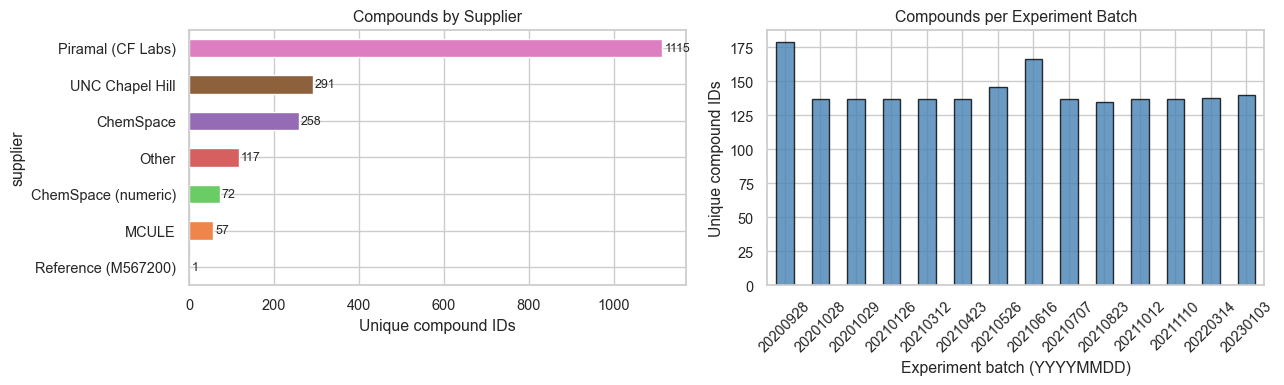

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

supplier_cpd = (
    raw.groupby("supplier")["compound_id"]
    .nunique()
    .sort_values(ascending=True)
)
supplier_cpd.plot.barh(ax=axes[0], color=sns.color_palette("muted", len(supplier_cpd)))
axes[0].set_xlabel("Unique compound IDs")
axes[0].set_title("Compounds by Supplier")
for i, v in enumerate(supplier_cpd.values):
    axes[0].text(v + 5, i, str(v), va="center", fontsize=9)

date_counts = (
    raw.groupby("reference_date")["compound_id"]
    .nunique()
    .sort_index()
)
date_counts.plot.bar(ax=axes[1], color="steelblue", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Experiment batch (YYYYMMDD)")
axes[1].set_ylabel("Unique compound IDs")
axes[1].set_title("Compounds per Experiment Batch")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

---
## 6. Filter to usable records

We need both a resolved SMILES and a measured pKD.

In [11]:
n_before = len(raw)
df = raw.dropna(subset=["smiles", "pKD"]).copy()
n_dropped = n_before - len(df)

display(Markdown(f"""
| Step | Records |
|------|--------|
| Starting | {n_before:,} |
| Dropped (missing SMILES or pKD) | {n_dropped:,} |
| **Remaining** | **{len(df):,}** |
"""))
assert len(df) > 0


| Step | Records |
|------|--------|
| Starting | 2,153 |
| Dropped (missing SMILES or pKD) | 328 |
| **Remaining** | **1,825** |


---
## 7. Remove ambiguous compound IDs

Some compound IDs map to multiple distinct SMILES. We exclude them.

In [12]:
smiles_per_id = df.groupby("compound_id")["smiles"].nunique()
ambiguous = smiles_per_id[smiles_per_id > 1].sort_values(ascending=False)

display(Markdown(f"**{len(ambiguous)} ambiguous compound IDs** map to >1 SMILES:"))
if len(ambiguous) > 0:
    amb_df = ambiguous.reset_index()
    amb_df.columns = ["compound_id", "n_distinct_smiles"]
    amb_df["supplier"] = amb_df["compound_id"].apply(assign_supplier)
    display(amb_df.head(15))

n_before = len(df)
unambiguous_ids = smiles_per_id[smiles_per_id == 1].index
df = df[df["compound_id"].isin(unambiguous_ids)].copy()

display(Markdown(f"Removed **{n_before - len(df):,}** records. Remaining: **{len(df):,}**"))

**0 ambiguous compound IDs** map to >1 SMILES:

Removed **0** records. Remaining: **1,825**

---
## 8. Average replicates within experiment batch

In [13]:
avg = (
    df.groupby(["compound_id", "reference_date"])
    .agg(
        smiles=("smiles", "first"),
        supplier=("supplier", "first"),
        pKD_mean=("pKD", "mean"),
        pKD_std=("pKD", "std"),
        n_replicates=("pKD", "count"),
        KD_M_mean=("KD_M", "mean"),
    )
    .reset_index()
)

display(Markdown(f"""
| Metric | Value |
|--------|-------|
| Averaged records (compound x batch) | {len(avg):,} |
| Unique compound IDs | {avg['compound_id'].nunique():,} |
| Unique SMILES | {avg['smiles'].nunique():,} |
| Median replicates per group | {avg['n_replicates'].median():.0f} |
| Max replicates per group | {avg['n_replicates'].max()} |
"""))


| Metric | Value |
|--------|-------|
| Averaged records (compound x batch) | 1,674 |
| Unique compound IDs | 1,600 |
| Unique SMILES | 1,588 |
| Median replicates per group | 1 |
| Max replicates per group | 18 |


---
## 9. Validate SMILES with RDKit

In [14]:
def validate_smiles(smi: str) -> dict:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {"canonical_smiles": None, "valid": False}
    return {"canonical_smiles": Chem.MolToSmiles(mol), "valid": True}


validated = avg["smiles"].apply(validate_smiles).apply(pd.Series)
avg = pd.concat([avg, validated], axis=1)

n_invalid = (~avg["valid"]).sum()
print(f"Invalid SMILES: {n_invalid}")
if n_invalid > 0:
    display(avg[~avg["valid"]][["compound_id", "smiles"]])

avg = avg[avg["valid"]].copy()
print(f"Records after validation: {len(avg):,}")

Invalid SMILES: 1


[19:08:49] SMILES Parse Error: syntax error while parsing: #N/A
[19:08:49] SMILES Parse Error: check for mistakes around position 1:
[19:08:49] #N/A
[19:08:49] ^
[19:08:49] SMILES Parse Error: Failed parsing SMILES '#N/A' for input: '#N/A'


,compound_id,smiles
56,960534930,#N/A


Records after validation: 1,673


---
## 10. Compute molecular properties

Chordoma Foundation design constraints: LogP ≤ 6, HBD ≤ 6, HBA ≤ 12, MW ≤ 600 Da

In [15]:
def compute_properties(smi: str) -> dict:
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {}
    return {
        "mw": Descriptors.ExactMolWt(mol),
        "logp": Descriptors.MolLogP(mol),
        "hbd": Lipinski.NumHDonors(mol),
        "hba": Lipinski.NumHAcceptors(mol),
        "heavy_atoms": mol.GetNumHeavyAtoms(),
        "num_rings": Descriptors.RingCount(mol),
        "tpsa": Descriptors.TPSA(mol),
        "rotatable_bonds": Descriptors.NumRotatableBonds(mol),
    }


props = avg["canonical_smiles"].apply(compute_properties).apply(pd.Series)
avg = pd.concat([avg, props], axis=1)

chordoma_mask = (
        (avg["logp"] <= 6)
        & (avg["hbd"] <= 6)
        & (avg["hba"] <= 12)
        & (avg["mw"] <= 600)
)
avg["passes_chordoma_filters"] = chordoma_mask

display(Markdown(f"**{chordoma_mask.sum()} / {len(avg)}** records "
                 f"({100 * chordoma_mask.mean():.1f}%) pass Chordoma filters."))

display(Markdown("### Property summary"))
display(avg[["mw", "logp", "hbd", "hba", "heavy_atoms", "tpsa", "pKD_mean"]].describe().round(2))

**1663 / 1673** records (99.4%) pass Chordoma filters.

### Property summary

,mw,logp,hbd,hba,heavy_atoms,tpsa,pKD_mean
count,1673.00,1673.00,1673.00,1673.00,1673.00,1673.00,1673.00
mean,358.52,2.88,1.60,4.44,25.56,76.11,3.10
std,75.74,1.08,0.91,1.70,5.44,25.08,1.65
min,179.06,-0.72,0.00,2.00,13.00,12.03,-1.42
25%,312.16,2.18,1.00,3.00,22.00,59.30,2.71
50%,346.18,2.92,2.00,4.00,25.00,75.43,3.26
75%,397.19,3.62,2.00,5.00,28.00,89.95,3.90
max,1088.34,6.23,5.00,18.00,76.00,277.09,12.41


---
## 11. QC Visuals

### 11a. SMILES counts and compound coverage by supplier

In [16]:
supplier_clean = (
    avg.groupby("supplier")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("canonical_smiles", "nunique"),
        median_pKD=("pKD_mean", "median"),
        pKD_gt_5=("pKD_mean", lambda x: (x > 5).sum()),
        pass_chordoma=("passes_chordoma_filters", "sum"),
    )
    .sort_values("unique_compounds", ascending=False)
)
supplier_clean.columns = [
    "Records", "Compounds", "SMILES", "Median pKD", "pKD>5 (hits)", "Pass Chordoma",
]
display(Markdown("### Cleaned data by supplier"))
display(supplier_clean)

### Cleaned data by supplier

,Records,Compounds,SMILES,Median pKD,pKD>5 (hits),Pass Chordoma
supplier,,,,,,
Piramal (CF Labs),1000,968,954,3.250643,62,993
UNC Chapel Hill,249,227,224,3.432347,14,247
ChemSpace,227,220,220,3.084613,3,227
Other,99,99,99,3.989959,12,99
ChemSpace (numeric),58,58,58,3.084780,3,58
MCULE,28,26,26,3.516976,1,27
Reference (M567200),12,1,1,3.256742,1,12


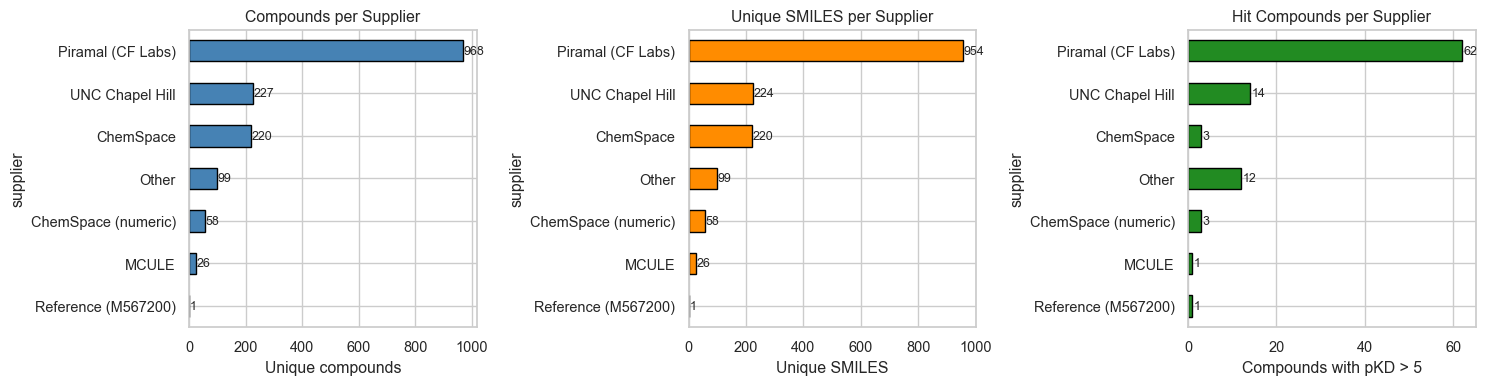

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sc = supplier_clean.sort_values("Compounds", ascending=True)
sc["Compounds"].plot.barh(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_xlabel("Unique compounds")
axes[0].set_title("Compounds per Supplier")
for i, v in enumerate(sc["Compounds"].values):
    axes[0].text(v + 2, i, str(v), va="center", fontsize=9)

sc["SMILES"].plot.barh(ax=axes[1], color="darkorange", edgecolor="black")
axes[1].set_xlabel("Unique SMILES")
axes[1].set_title("Unique SMILES per Supplier")
for i, v in enumerate(sc["SMILES"].values):
    axes[1].text(v + 2, i, str(v), va="center", fontsize=9)

sc["pKD>5 (hits)"].plot.barh(ax=axes[2], color="forestgreen", edgecolor="black")
axes[2].set_xlabel("Compounds with pKD > 5")
axes[2].set_title("Hit Compounds per Supplier")
for i, v in enumerate(sc["pKD>5 (hits)"].values):
    axes[2].text(v + 0.3, i, str(int(v)), va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 11b. Compounds per experiment batch

In [18]:
batch_summary = (
    avg.groupby("reference_date")
    .agg(
        records=("compound_id", "count"),
        unique_compounds=("compound_id", "nunique"),
        unique_smiles=("canonical_smiles", "nunique"),
        median_pKD=("pKD_mean", "median"),
        pKD_gt_5=("pKD_mean", lambda x: (x > 5).sum()),
    )
    .sort_index()
)
batch_summary.columns = ["Records", "Compounds", "SMILES", "Median pKD", "Hits (pKD>5)"]
batch_summary["Median pKD"] = batch_summary["Median pKD"].round(2)
display(Markdown("### Per-batch breakdown"))
display(batch_summary)

### Per-batch breakdown

,Records,Compounds,SMILES,Median pKD,Hits (pKD>5)
reference_date,,,,,
20200928,122,122,121,3.21,0
20201028,87,87,87,2.97,0
20201029,121,121,121,3.02,0
20210126,131,131,130,3.33,8
20210312,129,129,127,3.21,0
20210423,119,119,119,1.81,1
20210526,122,122,122,3.38,1
20210616,119,119,119,3.15,2
20210707,108,108,108,3.05,1


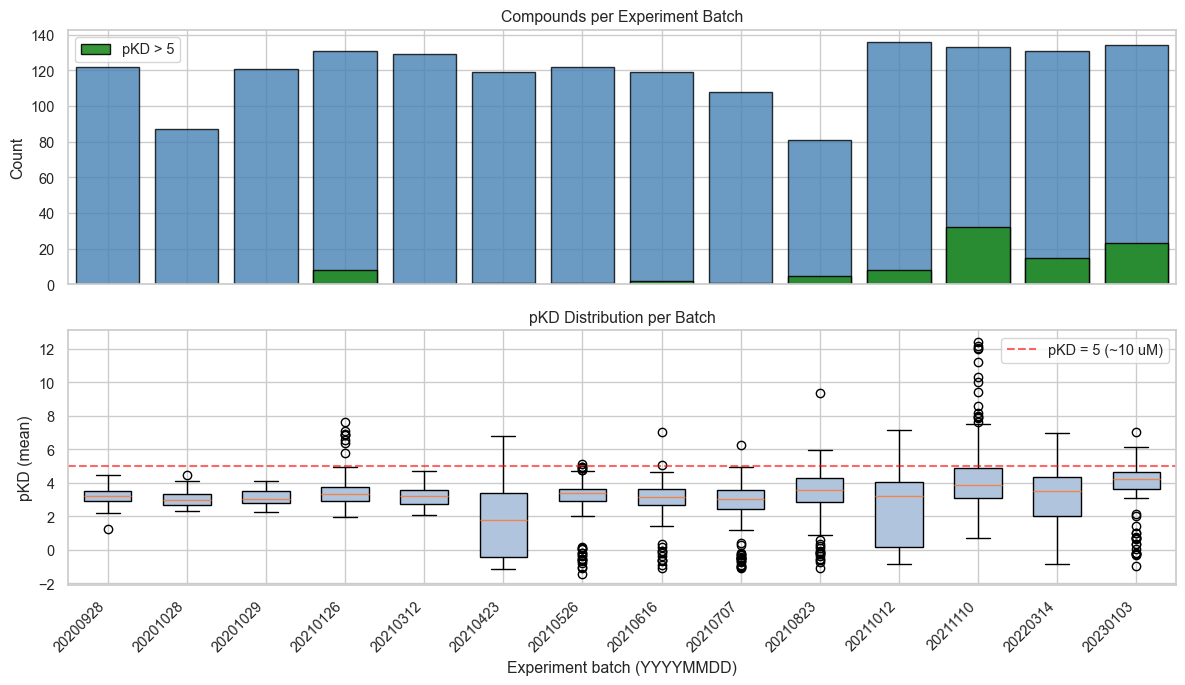

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

dates = batch_summary.index.astype(str)
x = np.arange(len(dates))

axes[0].bar(x, batch_summary["Compounds"], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].bar(x, batch_summary["Hits (pKD>5)"], color="forestgreen", edgecolor="black", alpha=0.9, label="pKD > 5")
axes[0].set_ylabel("Count")
axes[0].set_title("Compounds per Experiment Batch")
axes[0].legend()

ref_dates = sorted(avg["reference_date"].unique())
data_by_date = [avg[avg["reference_date"] == d]["pKD_mean"].values for d in ref_dates]
bp = axes[1].boxplot(data_by_date, positions=x, widths=0.6, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
axes[1].axhline(y=5.0, color="red", linestyle="--", alpha=0.6, label="pKD = 5 (~10 uM)")
axes[1].set_ylabel("pKD (mean)")
axes[1].set_title("pKD Distribution per Batch")
axes[1].set_xticks(x)
axes[1].set_xticklabels(dates, rotation=45, ha="right")
axes[1].set_xlabel("Experiment batch (YYYYMMDD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 11c. Property distributions

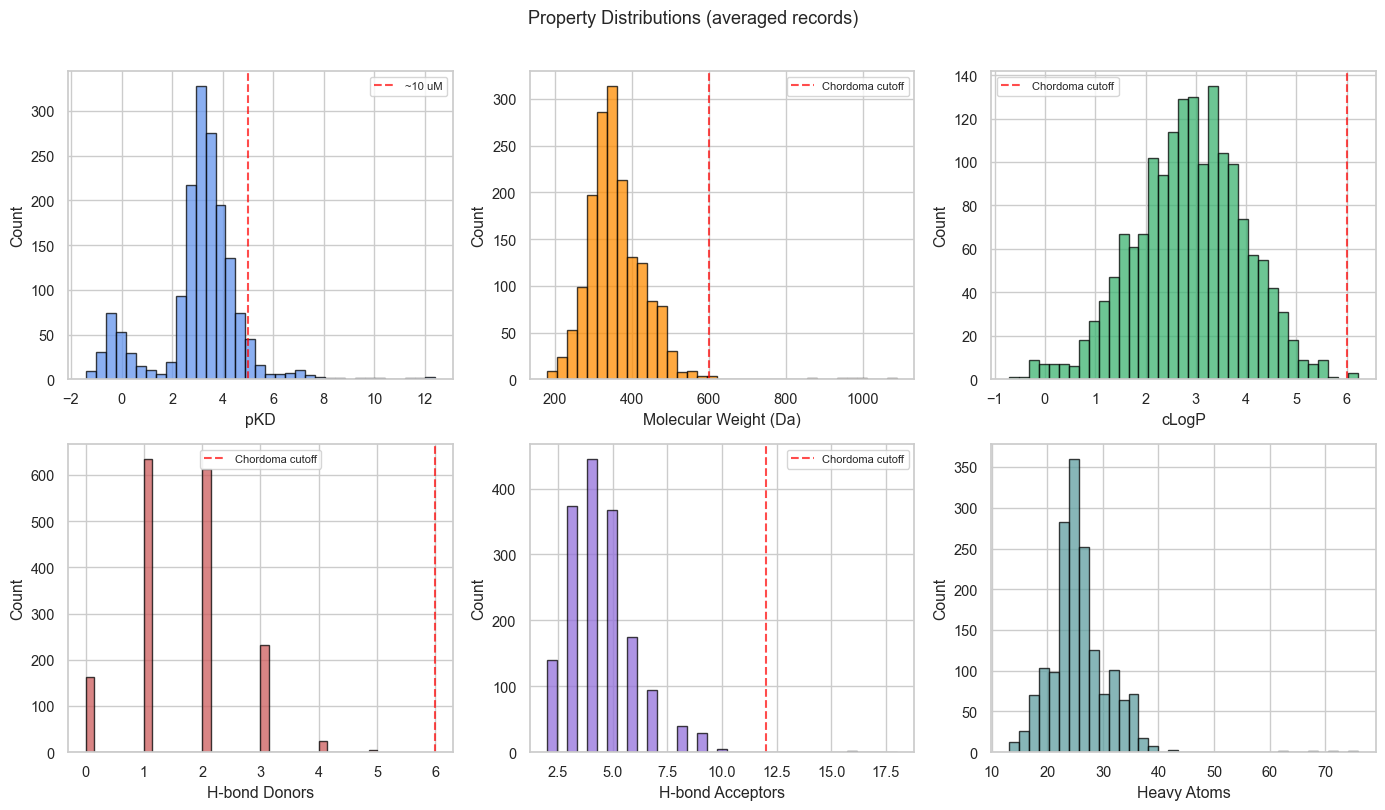

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

prop_configs = [
    ("pKD_mean", "pKD", "cornflowerblue", {"vline": 5.0, "label": "~10 uM"}),
    ("mw", "Molecular Weight (Da)", "darkorange", {"vline": 600, "label": "Chordoma cutoff"}),
    ("logp", "cLogP", "mediumseagreen", {"vline": 6, "label": "Chordoma cutoff"}),
    ("hbd", "H-bond Donors", "indianred", {"vline": 6, "label": "Chordoma cutoff"}),
    ("hba", "H-bond Acceptors", "mediumpurple", {"vline": 12, "label": "Chordoma cutoff"}),
    ("heavy_atoms", "Heavy Atoms", "cadetblue", {}),
]

for ax, (col, label, color, extras) in zip(axes.flat, prop_configs):
    data = avg[col].dropna()
    ax.hist(data, bins=35, color=color, edgecolor="black", alpha=0.75)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    if "vline" in extras:
        ax.axvline(x=extras["vline"], color="red", linestyle="--", alpha=0.7, label=extras["label"])
        ax.legend(fontsize=8)

fig.suptitle("Property Distributions (averaged records)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 11d. pKD vs. molecular properties

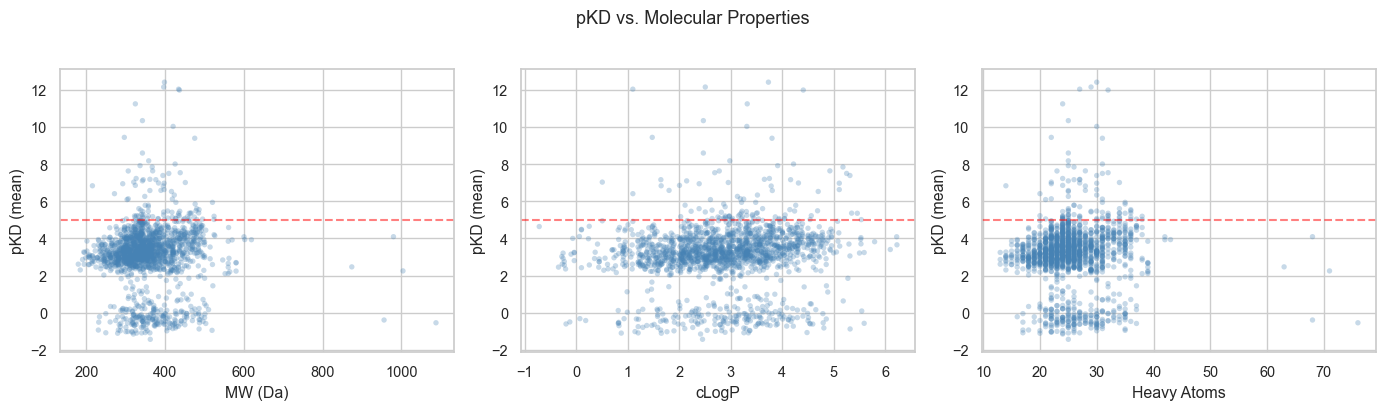

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (xcol, xlabel) in zip(axes, [("mw", "MW (Da)"), ("logp", "cLogP"), ("heavy_atoms", "Heavy Atoms")]):
    ax.scatter(avg[xcol], avg["pKD_mean"], alpha=0.3, s=15, c="steelblue", edgecolor="none")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("pKD (mean)")
    ax.axhline(y=5.0, color="red", linestyle="--", alpha=0.5)

fig.suptitle("pKD vs. Molecular Properties", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 12. Collapse to unique compounds

One row per compound: global mean pKD across all experiment batches.

In [22]:
compounds = (
    avg.groupby("compound_id")
    .agg(
        canonical_smiles=("canonical_smiles", "first"),
        supplier=("supplier", "first"),
        pKD_global_mean=("pKD_mean", "mean"),
        pKD_global_std=("pKD_mean", "std"),
        n_dates=("reference_date", "nunique"),
        mw=("mw", "first"),
        logp=("logp", "first"),
        hbd=("hbd", "first"),
        hba=("hba", "first"),
        heavy_atoms=("heavy_atoms", "first"),
        num_rings=("num_rings", "first"),
        tpsa=("tpsa", "first"),
        rotatable_bonds=("rotatable_bonds", "first"),
        passes_chordoma_filters=("passes_chordoma_filters", "first"),
    )
    .reset_index()
)

display(Markdown(f"""
### Final compound table

| Metric | Value |
|--------|-------|
| Unique compounds | {len(compounds):,} |
| Unique SMILES | {compounds['canonical_smiles'].nunique():,} |
| With pKD > 5 (~<10 uM) | {(compounds['pKD_global_mean'] > 5).sum()} |
| With pKD > 6 (~<1 uM) | {(compounds['pKD_global_mean'] > 6).sum()} |
| Pass Chordoma filters | {compounds['passes_chordoma_filters'].sum()} ({100 * compounds['passes_chordoma_filters'].mean():.1f}%) |
| Tested in >1 batch | {(compounds['n_dates'] > 1).sum()} |
"""))


### Final compound table

| Metric | Value |
|--------|-------|
| Unique compounds | 1,599 |
| Unique SMILES | 1,580 |
| With pKD > 5 (~<10 uM) | 87 |
| With pKD > 6 (~<1 uM) | 39 |
| Pass Chordoma filters | 1589 (99.4%) |
| Tested in >1 batch | 59 |


In [23]:
display(Markdown("### Top 15 compounds by pKD"))
top = compounds.sort_values("pKD_global_mean", ascending=False).head(15)
display(top[["compound_id", "supplier", "canonical_smiles", "pKD_global_mean", "mw", "logp", "n_dates"]].round(2))

### Top 15 compounds by pKD

,compound_id,supplier,canonical_smiles,pKD_global_mean,mw,logp,n_dates
734,CF-5-293,Piramal (CF Labs),O=C(NCc1ccccc1)c1cnc(Nc2ccc(Oc3ncccn3)cc2)nc1,12.41,398.15,3.73,1
674,CF-5-206,Piramal (CF Labs),CC(C)(C)OC(=O)NCCCNC(=O)Nc1ccc(Nc2ncnc3ccccc23...,11.98,436.22,4.41,1
429,CF-3-222,Piramal (CF Labs),COc1ccc(C)cc1NC(=O)CCNc1nc2ccccc2[nH]1,11.24,324.16,3.32,1
999,CF-9-21,Piramal (CF Labs),O=C(Nc1ccc(-c2nc(N3CCOCC3)ncc2F)cc1)C1CC1,10.34,342.15,2.47,1
988,CF-9-09,Piramal (CF Labs),O=C1Cc2cc(-c3cc(N4CCOCC4)ncn3)ccc2N1,9.44,296.13,1.47,1
1307,MCULE-4990117039,MCULE,CC(=O)NCc1ccc(-c2nc(NC(=O)Cc3csc(NC(=O)C4CC4)n...,9.39,475.08,3.80,1
1003,CF-9-25,Piramal (CF Labs),CCOC(=O)c1cnc(N2CCOCC2)nc1-c1ccc(NC(=O)C2CC2)cc1,8.79,396.18,2.51,2
992,CF-9-13,Piramal (CF Labs),O=C(Nc1ccc(-c2ncc(F)c(N3CCOCC3)n2)cc1)C1CC1,8.60,342.15,2.47,1
1000,CF-9-22,Piramal (CF Labs),O=C(Nc1ccc(-c2nc(N3CCOCC3)ncc2Cl)cc1)C1CC1,8.18,358.12,2.98,1
714,CF-5-265,Piramal (CF Labs),CC(=O)N1CCN(S(=O)(=O)N[C@H]2CCN(c3ccc(Cl)c(Cl)...,8.12,434.06,1.10,2


---
## 13. Export

Three files are written:

1. **`data/zenodo/tbxt_spr_merged.csv`** — full merged raw table (all records, pre-filter)
2. **`data/processed/tbxt_spr_averaged_by_date.csv`** — one row per (compound, experiment batch)
3. **`data/processed/tbxt_compounds_clean.csv`** — one row per unique compound (global mean pKD)

In [24]:
OUT_DIR = DATA_DIR / "processed"
OUT_DIR.mkdir(exist_ok=True)

avg_out = OUT_DIR / "tbxt_spr_averaged_by_date.csv"
avg.to_csv(avg_out, index=False)
assert len(avg) == len(pd.read_csv(avg_out))
print(f"Saved {len(avg):,} rows -> {avg_out}")

cpd_out = OUT_DIR / "tbxt_compounds_clean.csv"
compounds.to_csv(cpd_out, index=False)
assert len(compounds) == len(pd.read_csv(cpd_out))
print(f"Saved {len(compounds):,} rows -> {cpd_out}")

Saved 1,673 rows -> ../data/processed/tbxt_spr_averaged_by_date.csv
Saved 1,599 rows -> ../data/processed/tbxt_compounds_clean.csv


---
## Summary

This notebook processed **15 raw password-protected Excel files** from the HD Biosciences
TBXT SPR screening campaign. One batch (20210719) was excluded due to unresolvable compound
IDs, leaving 14 batches spanning October 2020 through January 2023.

**Output files:**
- `data/zenodo/tbxt_spr_merged.csv` (full merged raw table)
- `data/processed/tbxt_spr_averaged_by_date.csv` (averaged records)
- `data/processed/tbxt_compounds_clean.csv` (unique compounds for modeling)